In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import post_process, richardson_lucy
from smooth_POD_ROM.post_processing import get_sigma
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_hyperparameters_single, snapshots # , build_DSROM_g
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import delta_n_width, train_ROM, L2_error, zielfunktion, make_data_rw
from smooth_POD_ROM.plots_paper import Fig3, Fig4, Fig5, Fig6, Fig7, Fig8, Fig11
import warnings
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d as conv2
from scipy.interpolate._rgi_cython import evaluate_linear_2d, find_indices
from scipy.interpolate import (
    RegularGridInterpolator,
    RectBivariateSpline,
    interpn,
    griddata,
    Rbf,
    interp1d,
    interp2d,
)
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.signal import wiener
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
from datetime import datetime


8.030570172000001


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 25,
    "g": rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
}

In [4]:
# results for:
# n_x = 1000
# n_train = 10
# n_test = 25
# num_iter = 100
# clip = True
rank_all = [10, 20, 30, 50]
sigma_all = [0.03942593, 0.04462963, 0.01472222, 0.00856173]
c_all = [4.38271605, 2.65432099, 1.54320988, 1.66666667]
improvements_all = [ -72.8255, -59.2829, -49.7318, -54.6926]
# results for:
# n_x = 1000
# n_train = 10
# n_test = 10
# num_iter1 = 100
# num_iter2 = 1001
# clip = True
# rank = [10, 20, 30, 50]
# sigma = [0.08658411693500023, 0.06753569193117442, 0.04260935916899724, 0.01348455548077379]
# c = [2.147755288610398, 0.5273285959317914, 0.3269542485762022, 0.6772697328198871]
# improvements = [-82.8685,-72.4666, -64.0511, -60.1164]


In [5]:
# TEMP
# MOVE!

from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM


def smoothen_rowwise(X, sigma, shape):
    # sigma defined in terms of nodes not x!
    # consider passing sigma/dx to this function
    X_s = np.empty_like(X)
    for i in range(X.shape[0]):
        ss2D = X[i].reshape(shape)
        X_s[i] = gaussian_filter(ss2D, sigma=sigma, truncate=8, mode="wrap").ravel()
    return X_s


def snapshots_rowwise(g, x, mu):
    X = np.zeros((len(mu), len(x)))
    for j, mu_j in enumerate(mu):
        y = g(x, mu_j)
        X[j] = y
    return X


def make_data_rw(mu_min, mu_max, n_samples, g, x, sigma, **kwargs):
    dx = x[1] - x[0]
    mu = np.linspace(mu_min, mu_max, n_samples, endpoint=False)
    X = snapshots_rowwise(g, x, mu)
    sig = sigma / dx
    X_s = smoothen_rowwise(X, sig, x.shape)
    return mu, X, X_s


def train_ROM_rw(mu, X, rank=False):
    if not rank:
        rank = len(mu)  # no model truncation
    db = Database(mu, X)
    pod = POD(method="svd", rank=rank)  # = rom.reduction
    reg = RegularGrid()  # = rom.approximation
    rom = ROM(db, pod, reg)
    rom.fit()
    # pod.fit(db.snapshots.T)  # performs SVD
    # reduced_output = pod.transform(db.snapshots.T).T  # transform reduces the given snapshots. = VT.T
    # reg.fit(db.parameters, reduced_output)  # construct interpolators from points and values!
    return rom


def L2_error_rw(X, X_truth):
    L2 = np.mean((X - X_truth) ** 2, axis=1) ** 0.5
    return L2


def get_predictions(sROM, mu_test, sigma, c, num_iter, shape, x,
                    monitor_progress_postprocessing=False, monitor_convergence=False, **kwargs):
    X_test_sROM = sROM.predict(mu_test).snapshots_matrix
    mu_train = sROM.database.parameters_matrix
    data = X_test_sROM
    
    # from datetime import datetime
    if monitor_convergence:
        deconvolved = np.ones((*data.shape, num_iter))
    else:
        deconvolved = np.empty_like(data)
    for j in range(len(mu_test)):
        sgm_est = get_sigma(sigma, mu_test[j][None, ...], mu_train, c=c)
        # t1 = datetime.now()
        deconvolved[j] = richardson_lucy(
            x,
            data[j].reshape(shape),
            sgm_est,
            num_iter,
            monitor_convergence=monitor_convergence,
        ).reshape(deconvolved[j].shape)
        # print("sgm=", sgm_est*1000, (datetime.now()-t1).total_seconds())
        if monitor_progress_postprocessing:
            print(j, end=", ")
    X_test_sROMs = deconvolved
    return X_test_sROM, X_test_sROMs


def get_improvement(X_test, X_test_ROM, X_test_sROM, X_test_sROMs):
    e_ROM = L2_error_rw(X_test_ROM, X_test)
    mean_ROM = np.mean(e_ROM)
    e_sROM = L2_error_rw(X_test_sROM, X_test)
    mean_sROM = np.mean(e_sROM)
    e_sROMs = L2_error_rw(X_test_sROMs, X_test)
    mean_sROMs = np.mean(e_sROMs)
    improvement = 100 * mean_sROMs / mean_ROM - 100
    return mean_ROM, mean_sROM, mean_sROMs, improvement

In [6]:
def target_function(case):
    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(X_test, X_test_ROM, X_test_sROM, X_test_sROMs)
    print(
        "{:.0f}, {:.8f}, {:.8f}, {:.8f}, {:.8f}, {:.8f}, {:.4f}".format( case["num_iter"],  case["sigma"], case["c"], mean_ROM, mean_sROM, mean_sROMs, improvement)
        )
    return improvement

def optimize_hyperparameters(case):
    rank = case["n_train"]
    sigma_opt = 1 / (rank * 2)
    x0 = np.array([sigma_opt, 1.0])
    counter = np.array([0])

    def target(params):
        case["sigma"], case["c"] = params[0], params[1]
        return target_function(case)

    # res = minimize(
    #     target,
    #     x0,
    #     method="SLSQP",
    #     bounds=[(0.001, 5 * sigma_opt), (0, 10)],
    #     options={"disp": True, "eps": np.array([0.0005, 0.05]), "maxiter": 25, "ftol": 0.0005},
    # )
    bounds = Bounds([0.001, 0], [5 * sigma_opt, 10])
    res = result = direct(target, bounds, eps=1e-2, len_tol=0.025)  # max side length_abs=[0.006, 0.25]
    return res["x"]

In [7]:
case["num_iter"] = 100
for i in range(4):
    case["n_train"] = rank_all[i]
    case["sigma"] = sigma_all[i]
    case["c"] = c_all[i]
    
    parameters = optimize_hyperparameters(case)

    print("- - - - - - - - - - - - - - - - - - - - - - - - - ")
    case["n_train"] = rank_all[i]
    case["sigma"] = sigma_all[i]
    case["c"] = c_all[i]
    target_function(case)
    print("- - - - - - - - - - - - - - - - - - - - - - - - - ")
    case["sigma"] = parameters[0]
    case["c"] = parameters[1]
    target_function(case)
    print("- - - - - - - - - - - - - - - - - - - - - - - - - ")

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


100, 0.12550000, 5.00000000, 0.19080839, 0.23283547, 0.13329016, -30.1445
100, 0.20850000, 5.00000000, 0.19080839, 0.24945891, 0.21608790, 13.2486
100, 0.04250000, 5.00000000, 0.19080839, 0.18440992, 0.05263790, -72.4132
100, 0.12550000, 8.33333333, 0.19080839, 0.23283547, 0.17153152, -10.1027
100, 0.12550000, 1.66666667, 0.19080839, 0.23283547, 0.09194566, -51.8126
100, 0.04250000, 8.33333333, 0.19080839, 0.18440992, 0.05828879, -69.4517
100, 0.04250000, 1.66666667, 0.19080839, 0.18440992, 0.07629535, -60.0147
100, 0.20850000, 8.33333333, 0.19080839, 0.24945891, 0.24168894, 26.6658
100, 0.20850000, 1.66666667, 0.19080839, 0.24945891, 0.16807788, -11.9127
100, 0.07016667, 5.00000000, 0.19080839, 0.20647291, 0.06705277, -64.8586
100, 0.01483333, 5.00000000, 0.19080839, 0.17377907, 0.18798811, -1.4781
100, 0.04250000, 6.11111111, 0.19080839, 0.18440992, 0.05407019, -71.6626
100, 0.04250000, 3.88888889, 0.19080839, 0.18440992, 0.05229354, -72.5937
100, 0.07016667, 3.88888889, 0.19080839, 

In [8]:
# Results from SLSQP for rank 10, 20, 30, 50
# 100, 0.03646128, 4.99222927, 0.19080839, 0.17958300, 0.05171203, -72.8985
# 100, 0.04492240, 2.55252688, 0.12313309, 0.16628224, 0.05013127, -59.2869
# 100, 0.02332058, 0.88578413, 0.09915827, 0.11522427, 0.05024713, -49.3263
# 100, 0.00828402, 1.70336367, 0.07731714, 0.07488915, 0.03507394, -54.6363

# Results from DIRECT for rank 10, 20, 30, 50
# 100, 0.03942593, 4.38271605, 0.19080839, 0.18189029, 0.05185121, -72.8255
# 100, 0.04462963, 2.65432099, 0.12313309, 0.16580169, 0.05013620, -59.2829
# 100, 0.01472222, 1.54320988, 0.09915827, 0.09796930, 0.04984510, -49.7318
# 100, 0.00856173, 1.66666667, 0.07731714, 0.07542985, 0.03503037, -54.6926

generate snapshots
build ROM and predict
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.0
1 0.0025
2 0.005
3 0.0075
4 0.01
5 0.0125
6 0.015
7 0.0175
8 0.02
9 0.0225
10 0.025
11 0.0275
12 0.03
13 0.0325
14 0.035
15 0.0375
16 0.04
17 0.0425
18 0.045
19 0.0475
20 0.05
21 0.0525
22 0.055
23 0.0575
24 0.06
25 0.0625
26 0.065
27 0.0675
28 0.07
29 0.0725
30 0.075
31 0.0775
32 0.08
33 0.0825
34 0.085
35 0.08750000000000001
36 0.09
37 0.0925
38 0.095
39 0.0975
40 0.1
41 0.10250000000000001
42 0.105
43 0.1075
44 0.11
45 0.1125
46 0.115
47 0.11750000000000001
48 0.12
49 0.1225
50 0.125
51 0.1275
52 0.13
53 0.1325
54 0.135
55 0.1375
56 0.14
57 0.14250000000000002
58 0.145
59 0.1475
60 0.15
61 0.1525
62 0.155
63 0.1575
64 0.16
65 0.1625
66 0.165
67 0.1675
68 0.17
69 0.17250000000000001
70 0.17500000000000002
71 0.1775
72 0.18
73 0.1825
74 0.185
7

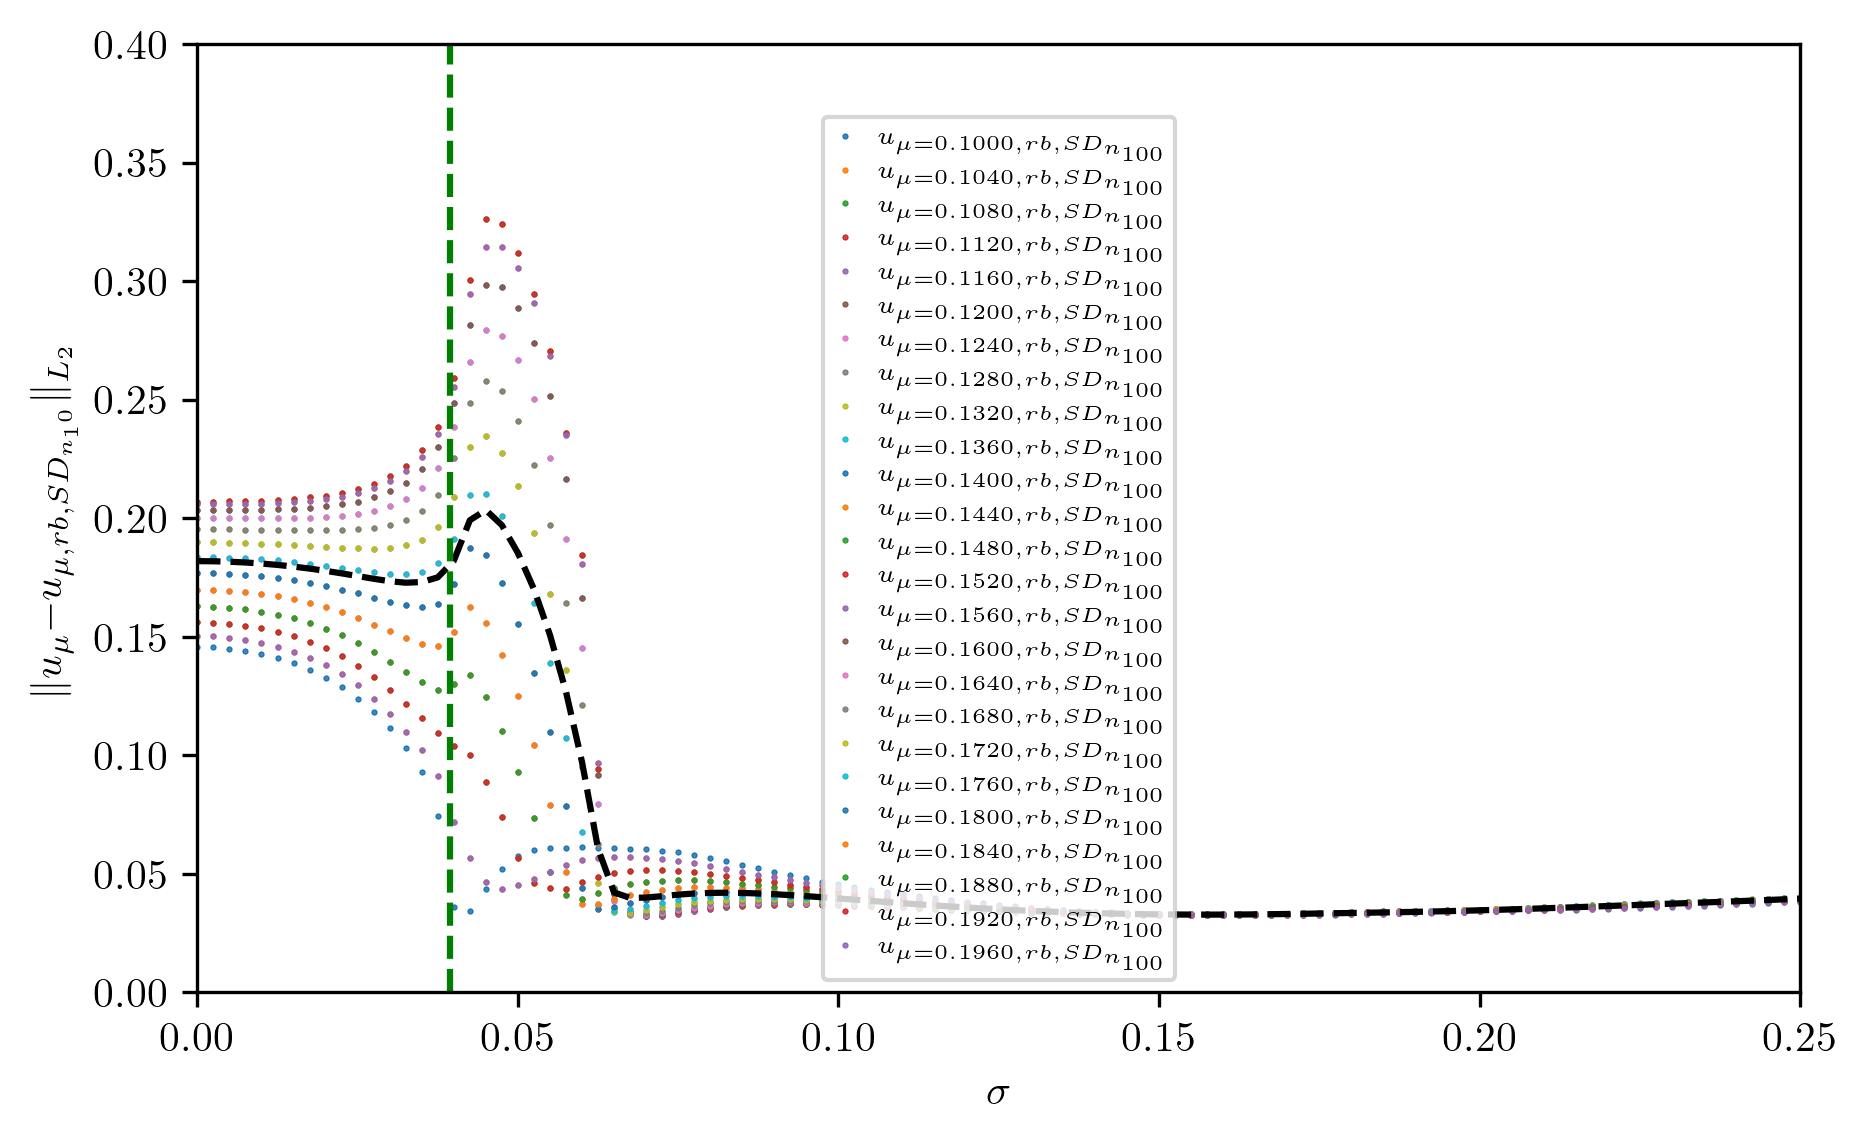

generate snapshots
build ROM and predict
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.0
1 0.00125
2 0.0025
3 0.00375
4 0.005
5 0.00625
6 0.0075
7 0.00875
8 0.01
9 0.01125
10 0.0125
11 0.01375
12 0.015
13 0.01625
14 0.0175
15 0.01875
16 0.02
17 0.02125
18 0.0225
19 0.02375
20 0.025
21 0.02625
22 0.0275
23 0.02875
24 0.03
25 0.03125
26 0.0325
27 0.03375
28 0.035
29 0.03625
30 0.0375
31 0.03875
32 0.04
33 0.04125
34 0.0425
35 0.043750000000000004
36 0.045
37 0.04625
38 0.0475
39 0.04875
40 0.05
41 0.051250000000000004
42 0.0525
43 0.05375
44 0.055
45 0.05625
46 0.0575
47 0.058750000000000004
48 0.06
49 0.06125
50 0.0625
51 0.06375
52 0.065
53 0.06625
54 0.0675
55 0.06875
56 0.07
57 0.07125000000000001
58 0.0725
59 0.07375
60 0.075
61 0.07625
62 0.0775
63 0.07875
64 0.08
65 0.08125
66 0.0825
67 0.08375
68 0.085
69 0.08625000000000001
7

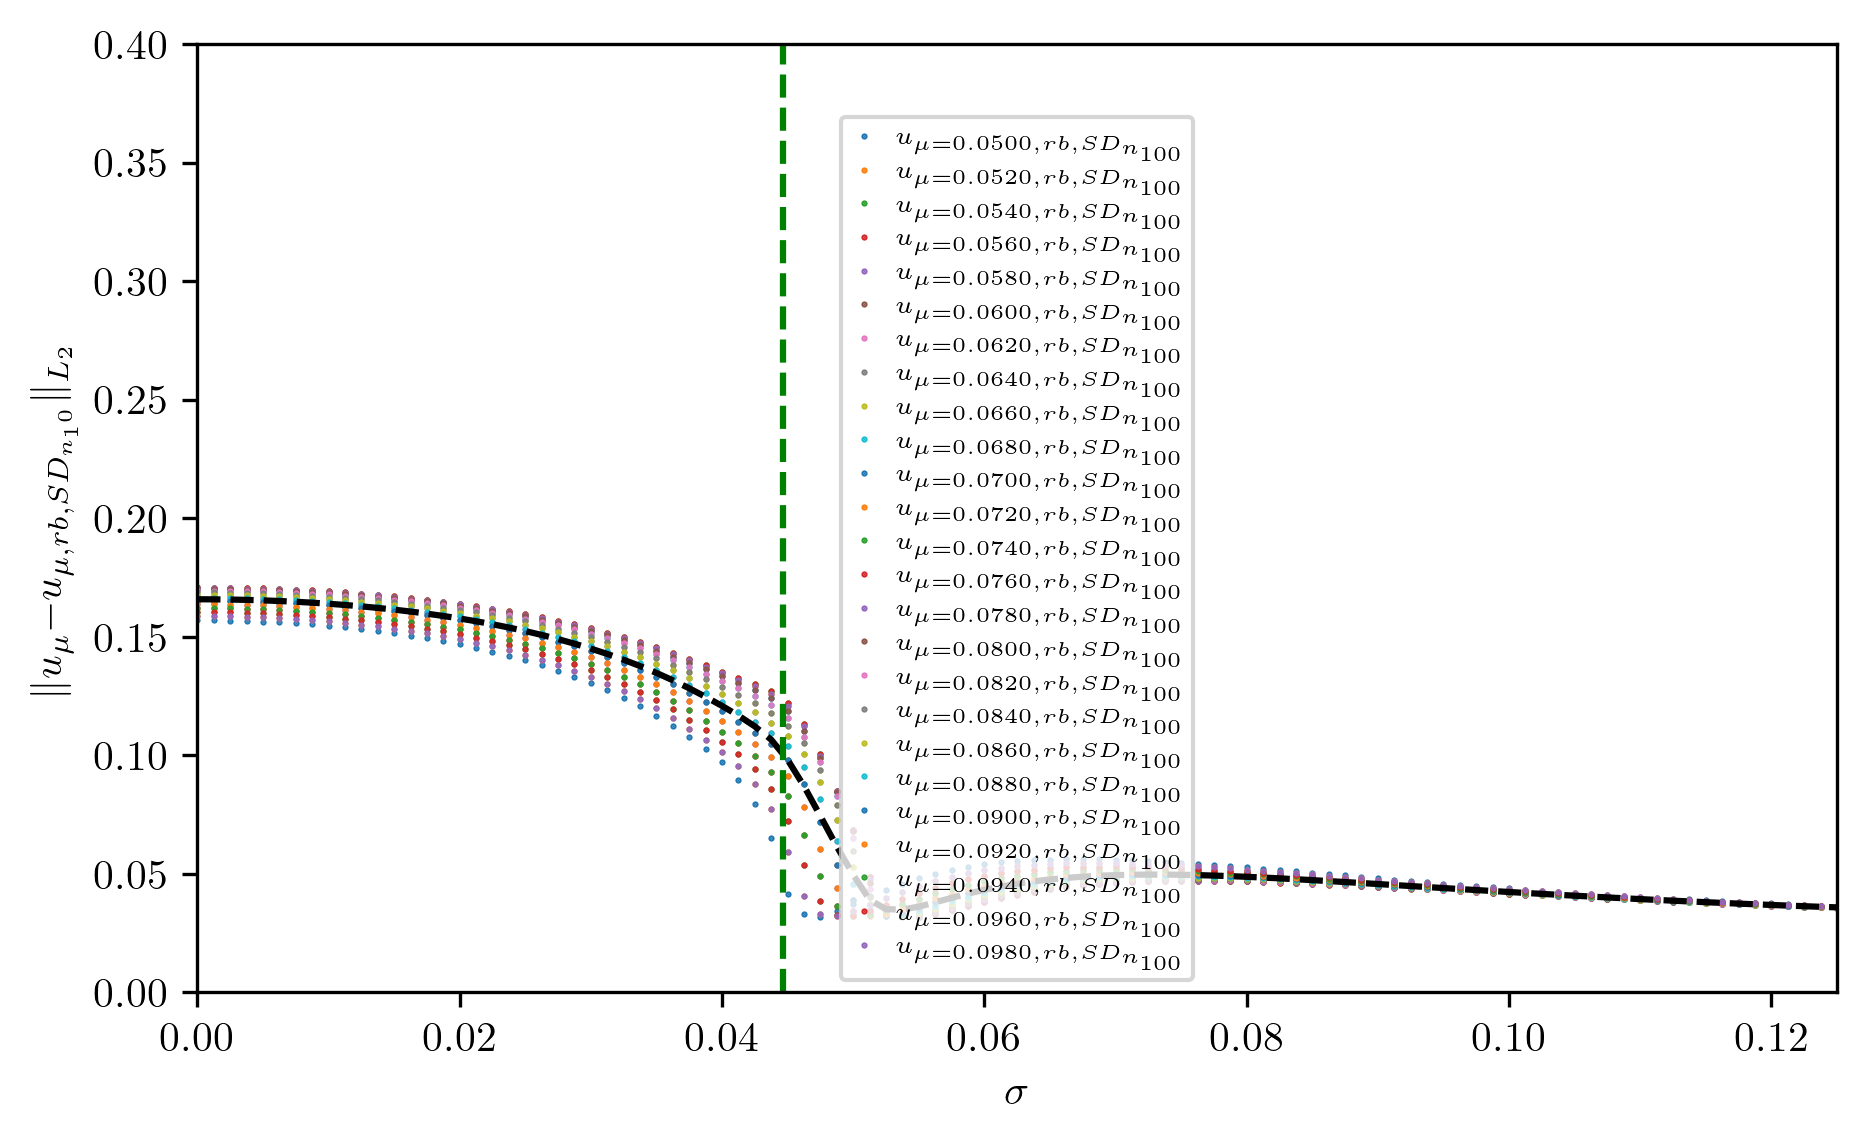

generate snapshots
build ROM and predict
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.0
1 0.0008333333333333333
2 0.0016666666666666666
3 0.0024999999999999996
4 0.003333333333333333
5 0.004166666666666667
6 0.004999999999999999
7 0.005833333333333333
8 0.006666666666666666
9 0.0075
10 0.008333333333333333
11 0.009166666666666667
12 0.009999999999999998
13 0.010833333333333332
14 0.011666666666666665
15 0.012499999999999999
16 0.013333333333333332
17 0.014166666666666666
18 0.015
19 0.01583333333333333
20 0.016666666666666666
21 0.017499999999999998
22 0.018333333333333333
23 0.019166666666666665
24 0.019999999999999997
25 0.020833333333333332
26 0.021666666666666664
27 0.0225
28 0.02333333333333333
29 0.024166666666666666
30 0.024999999999999998
31 0.025833333333333333
32 0.026666666666666665
33 0.027499999999999997
34 0.028333333

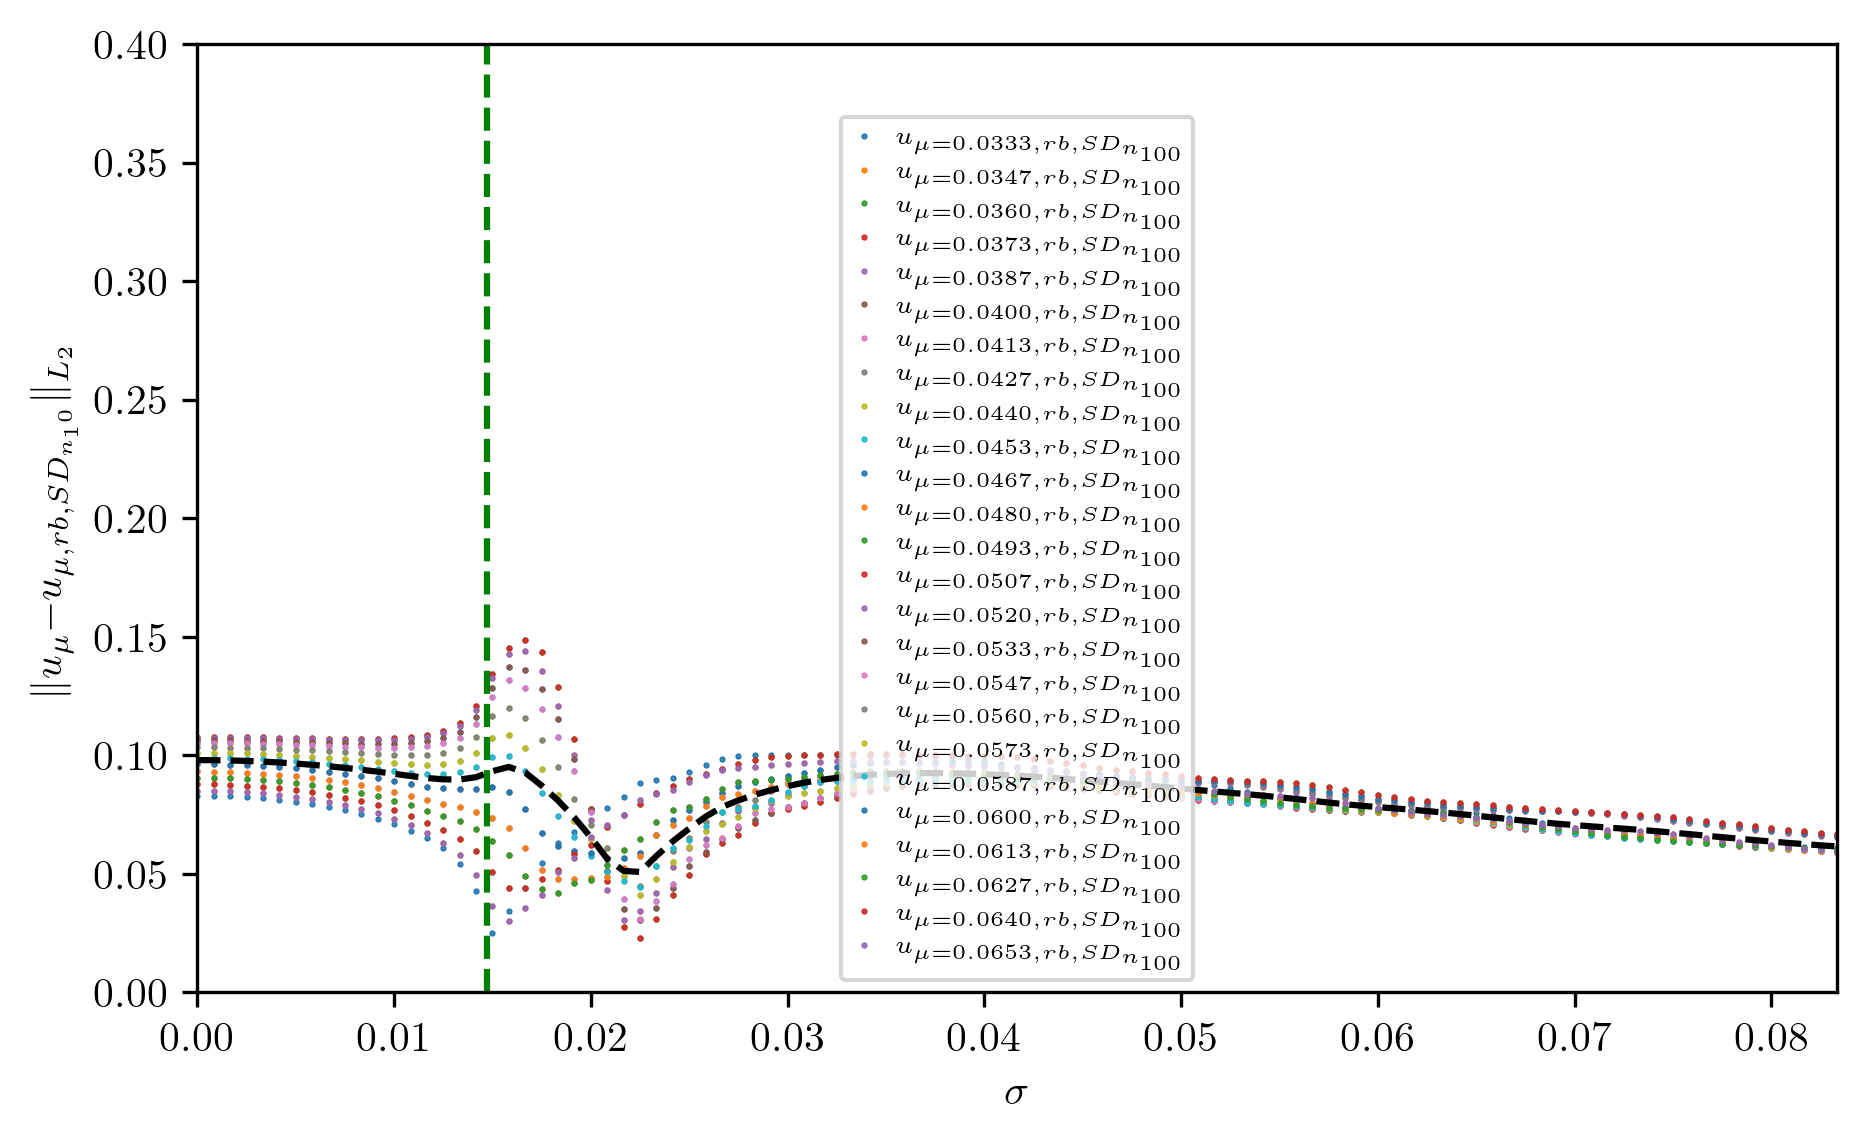

generate snapshots
build ROM and predict
we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot
SigmaD is varied and we see what happens with the error with the number of iterations in RL
0 0.0
1 0.0005
2 0.001
3 0.0015
4 0.002
5 0.0025
6 0.003
7 0.0035
8 0.004
9 0.0045000000000000005
10 0.005
11 0.0055
12 0.006
13 0.006500000000000001
14 0.007
15 0.0075
16 0.008
17 0.0085
18 0.009000000000000001
19 0.0095
20 0.01
21 0.0105
22 0.011
23 0.0115
24 0.012
25 0.0125
26 0.013000000000000001
27 0.0135
28 0.014
29 0.0145
30 0.015
31 0.0155
32 0.016
33 0.0165
34 0.017
35 0.0175
36 0.018000000000000002
37 0.0185
38 0.019
39 0.0195
40 0.02
41 0.0205
42 0.021
43 0.021500000000000002
44 0.022
45 0.0225
46 0.023
47 0.0235
48 0.024
49 0.0245
50 0.025
51 0.025500000000000002
52 0.026000000000000002
53 0.0265
54 0.027
55 0.0275
56 0.028
57 0.0285
58 0.029
59 0.029500000000000002
60 0.03
61 0.0305
62 0.031
63 0.0315
64 0.032
65 0.0325
66 0.033
67 0.0335

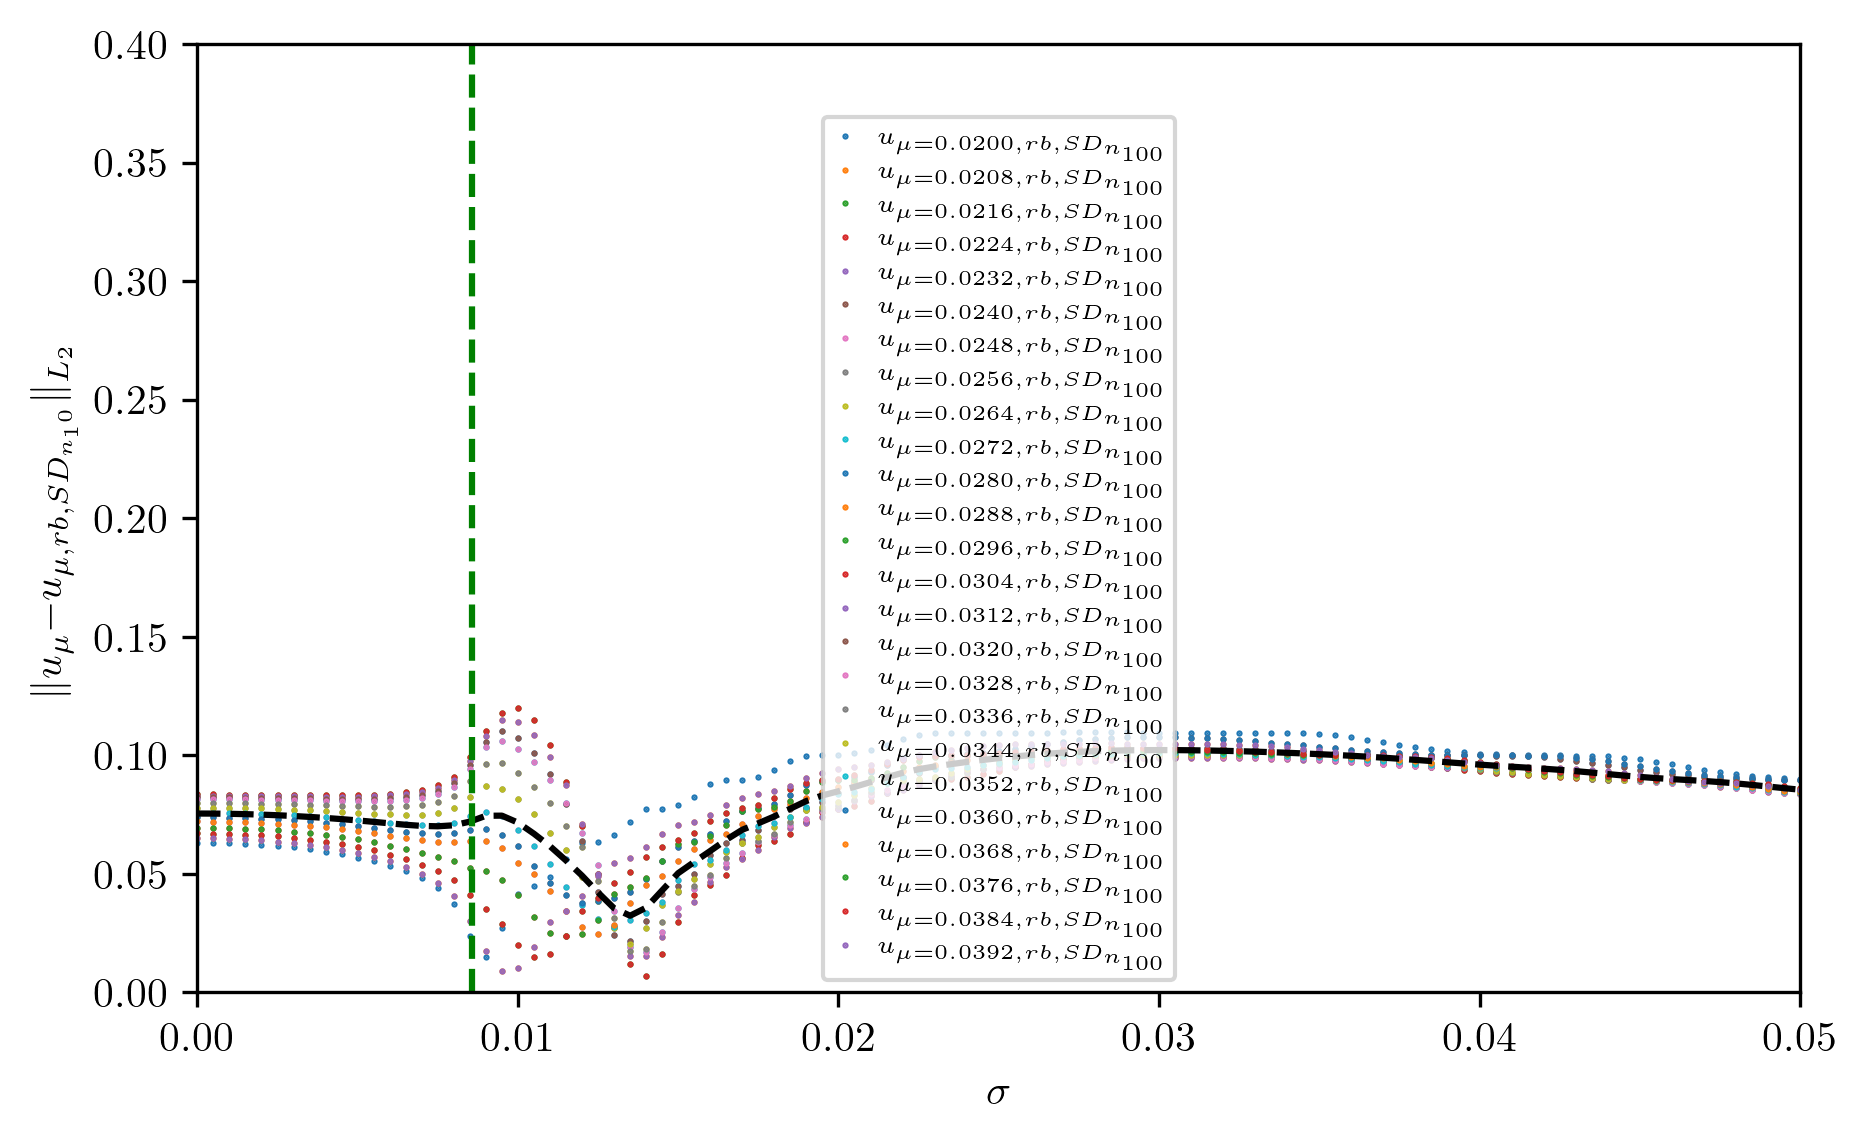

In [9]:
for i, _rank, _sigma, _c in zip((1, 2, 3, 4), rank_all, sigma_all, c_all):
    print("generate snapshots")
    print("build ROM and predict")
    n_train = _rank
    case["n_train"] = _rank
    case["rank"] = _rank
    case["sigma"] = _sigma
    case["c"] = _c
    num_iter = 555
    shape = case["shape"]

    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)

    print("we fixed sigmaS to some value (spoiler: it was optimized) and see how the error behaves for each snapshot")
    print("SigmaD is varied and we see what happens with the error with the number of iterations in RL")
    #deconvolved = np.ones((*data.shape, num_iter))
    sigmaDs = np.linspace(0, 5 / (_rank * 2), 101)
    X_test_sROMs = np.empty((case["n_test"], n_x, num_iter, len(sigmaDs)))  # i, j, m, n
    for n, sigmaD in enumerate(sigmaDs):
        print(n, sigmaD)
        for i in range(len(mu_test)):
            X_test_sROMs[i, :, :, n] = richardson_lucy(
                x,
                X_test_sROM[i].reshape(shape),
                sigmaD,
                num_iter,
                monitor_convergence=True,
            ).reshape((n_x, num_iter))

    esROMs = L2_error_rw(X_test_sROMs, X_test[..., None, None])

    fig, ax = plt.subplots(figsize=(plot_width_in*2, plot_width_in*2/1.61803398875))
    for i in range(case["n_test"]):
        plt.plot(sigmaDs, esROMs[i, -1], marker=".", ms=1, lw=0, label=r"$u_{\mu="+"{:.4f}".format(mu_test[i, 0])+",rb,SD_{n_{100}}}$")
    plt.plot(sigmaDs, np.mean(esROMs[:, -1, :], axis=0), "k--")
    plt.plot((_sigma, _sigma), (0, 0.4), "g--")
    plt.legend()
    plt.xlim(0, sigmaDs[-1])
    plt.ylim(0, .4)
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_10}}}\|_{L_2}$")
    plt.xlabel(r"$\sigma$")
    plt.show()

(25, 555, 101)
0.00856173, 1.66666667, 0, 0.10000000, 0.20000000, 0.08253116, 99.9990 %


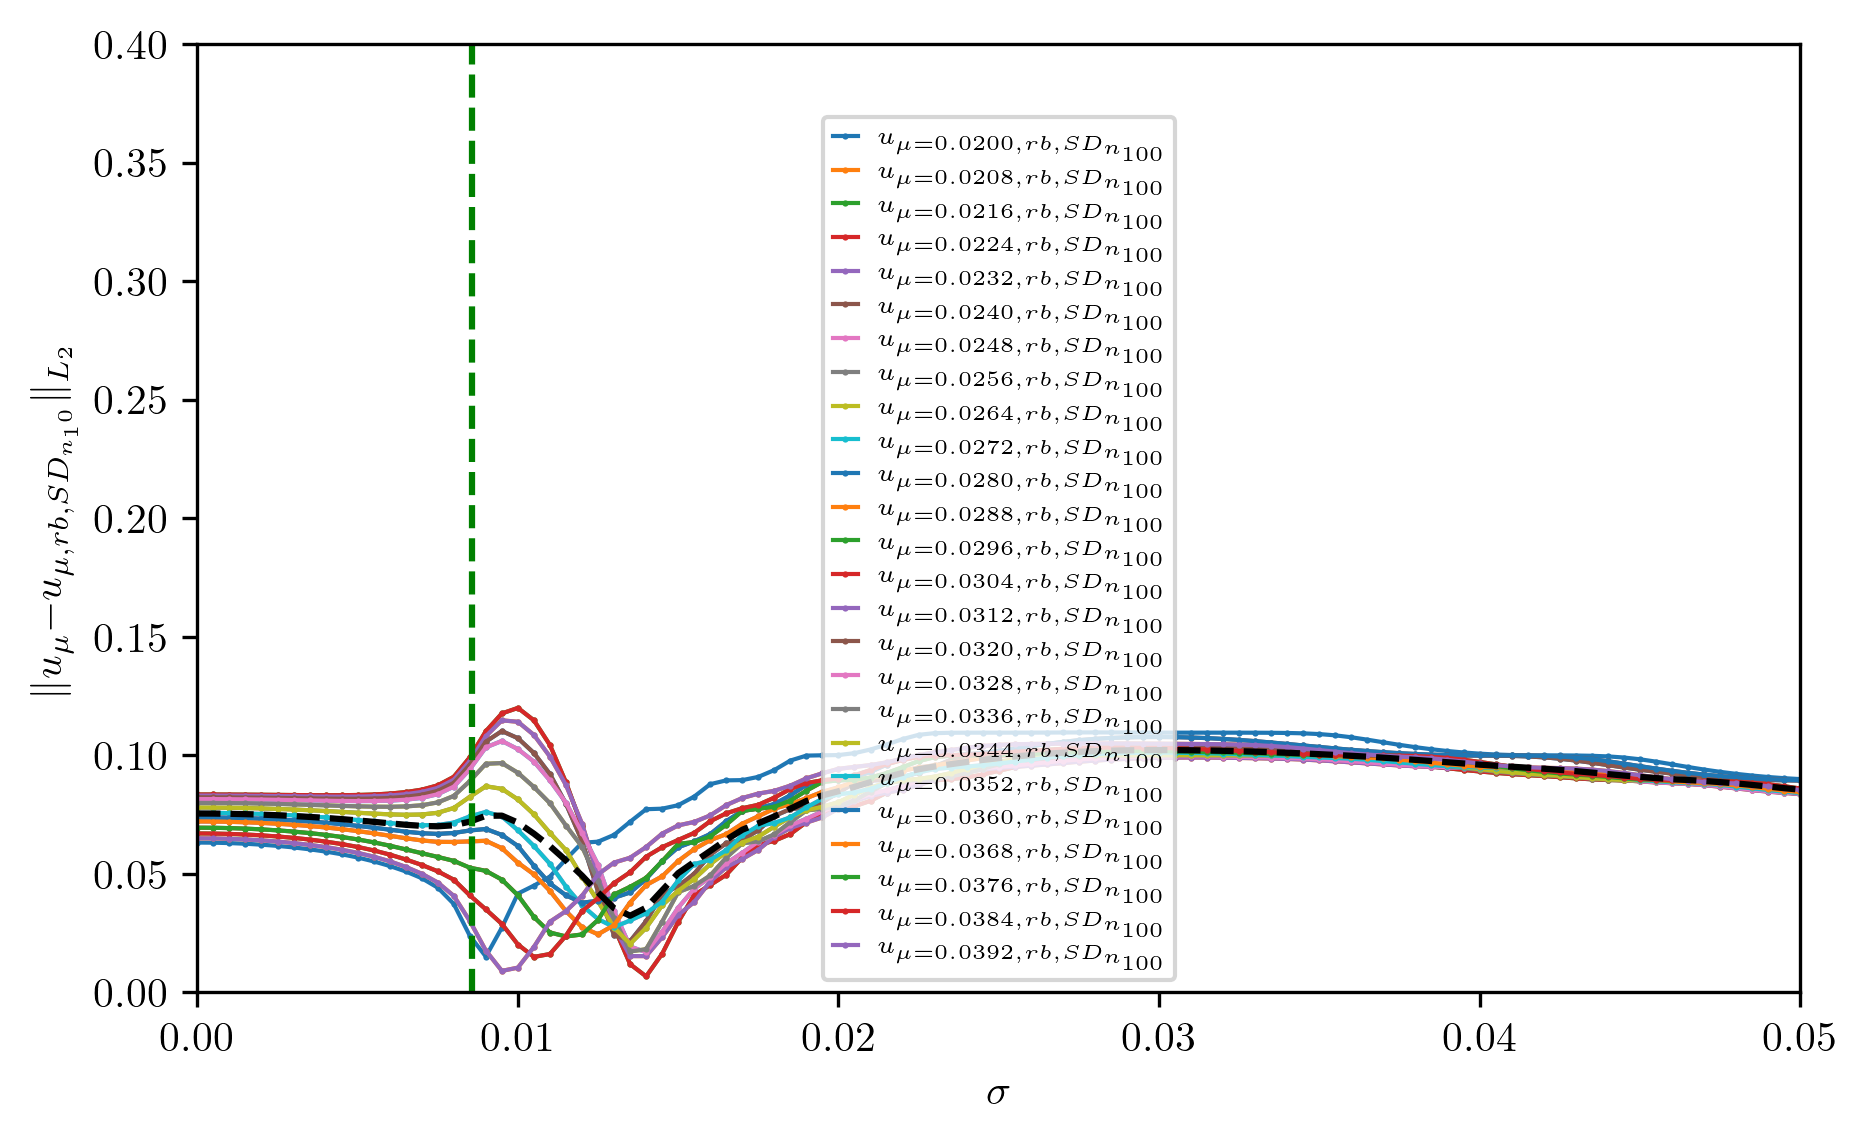

In [10]:
    esROMs = L2_error_rw(X_test_sROMs, X_test[..., None, None])
    print(esROMs.shape)
    print(
        "{:.8f}, {:.8f},".format(_sigma, _c),
        "{:.0f}, {:.8f}, {:.8f}, {:.8f}, {:.4f} %".format(
            0, .1, .2, np.mean(esROMs), 99.999
        ),
    )

    fig, ax = plt.subplots(figsize=(plot_width_in*2, plot_width_in*2/1.61803398875))
    for i in range(case["n_test"]):
        plt.plot(sigmaDs, esROMs[i, -1], marker=".", ms=1, lw=1, label=r"$u_{\mu="+"{:.4f}".format(mu_test[i, 0])+",rb,SD_{n_{100}}}$")
    plt.plot(sigmaDs, np.mean(esROMs[:, -1, :], axis=0), "k--")
    plt.plot((_sigma, _sigma), (0, 0.4), "g--")
    plt.legend()
    plt.xlim(0, sigmaDs[-1])
    plt.ylim(0, .4)
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb, SD_{n_10}}}\|_{L_2}$")
    plt.xlabel(r"$\sigma$")
    plt.show()

ValueError: x and y can be no greater than 2D, but have shapes (1000,) and (1000, 555, 101)

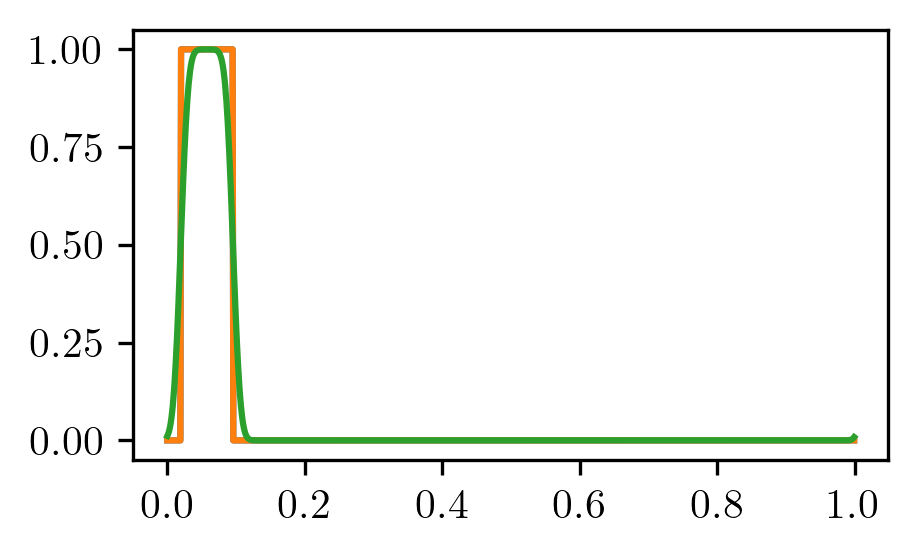

In [11]:
for i in range(10):
    plt.plot(case["x"], X_test[i])
    plt.plot(case["x"], X_test_ROM[i])
    plt.plot(case["x"], X_test_sROM[i])
    plt.plot(case["x"], X_test_sROMs[i])
    plt.show()